# Phase 3: Real-Time Walk-Forward Evaluation for F10.7 Forecasting

## Objective
Establish a **realistic, real-time evaluation framework** for predicting daily F10.7 values **`H` days ahead**.

The primary goal of Phase 3 is to determine whether any model can **consistently outperform a persistence baseline** under strict, deployment-faithful conditions, with a focus on **Solar Cycle 25**.

This phase prioritizes **evaluation correctness and scope control** over model complexity.

---

## Core Evaluation Contract
All models in Phase 3 must follow the same evaluation rules:

- **Prediction task:** Predict F10.7 at *t + `H` days*
- **Evaluation window:** Solar Cycle 25 only
- **Validation method:** Strict walk-forward evaluation
- **Training window:** Expanding window using all data available up to time *t*
- **No data leakage:**
  - No future data used for training or scaling
  - Any preprocessing (e.g., scaling) must be fit on training data only

For each day *t* in Cycle 25:
1. Train the model on data up to day *t*
2. Predict F10.7 for day *t + `H`*
3. Log prediction, true value, and errors
4. Advance by one day and repeat

---

## Baseline Definition
**Persistence Baseline**

- Forecast: F10.7 at *t + `H`* equals observed F10.7 at *t*
- Evaluated using the exact same walk-forward timestamps as all ML models

This baseline defines the **minimum performance bar**.

---

## Success Criteria
A model is considered useful only if it:

- Beats persistence on **aggregate MAE**
- Beats persistence on **aggregate RMSE**
- Beats persistence on **more than 50% of individual prediction days**, measured by lower **absolute error per day**

---

## Metrics
- **Primary:** MAE (sfu)
- **Secondary:** RMSE (sfu)

All errors are reported in **solar flux units (sfu)**.

---

## Data and Features

### Raw Inputs (extracted upfront)
- F10.7 solar flux
- Sunspot number (SSN)
- ap index

Not all inputs must be used by every model.

### Feature Engineering (initial)
- Lagged F10.7 values: 1 to 27 days
- Lagged Ap values: 1 to 27 days
- Ap Mean
- Ap Max

Additional features may be introduced iteratively and must be **explicitly logged** when added.

---

## Model Scope
Models will be introduced incrementally, in roughly the following order:
1. Persistence
2. Linear regression variants
3. Random Forest
4. Gradient Boosted Trees
5. RNN / LSTM

Each model may use inputs appropriate to its strengths, but all models must adhere to the same evaluation contract.

---

## Philosophy
Phase 3 is an **exploratory benchmark**:
- Results are expected to evolve
- Changes are allowed, but must be documented
- No result is overwritten or hidden

---

## Export
*After model evaluation on Solar Cycle 25*, final serialized models are **retrained on the full available dataset** to maximize deployable performance.

## Next Steps
1. Continue exporting serialized models as performance improves
2. Introduce and evaluate nonlinear models:
    - RNN / LSTM sequence models
    - RBF-SVM regression
3. Compare models across multiple horizons (H = 1, 7)
4. Visualize:
    - Prediction vs actual time series (Cycle 25)
    - Error distributions
    - Day-level win rate vs persistence

# Configuration

Defines global constants used throughout phase 3 to avoid hidden assumptions.

In [1]:
import pandas as pd
import os

CONFIG = {
    "HORIZON_DAYS": 7,
    "N_LAGS": 27,
    "CYCLE_NAME": "Solar Cycle 25",
    "CYCLE25_START": None,  # set explicitly later
    "RANDOM_SEED": 42,
    "DATA_PATH": "datasets/Kp_ap_Ap_SN_F107_since_1932.txt",
    "CYCLE25_START": pd.Timestamp("2019-12-01")
}

## Model Metrics Export

In [2]:
import os
import pandas as pd

def log_metrics(model_name, mae, rmse, file_path="phase3_metrics.csv"):
    new_row = pd.DataFrame([{
        "model": model_name,
        "mae": mae,
        "rmse": rmse
    }])

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        if model_name in df["model"].values:
            df.loc[df["model"] == model_name, ["mae", "rmse"]] = [mae, rmse]
        else:
            df = pd.concat([df, new_row], ignore_index=True)

        df.to_csv(file_path, index=False)

    else:
        new_row.to_csv(file_path, index=False)

In [3]:
def load_metrics(filter_regex=None, file_path="phase3_metrics.csv"):
    df = pd.read_csv(file_path)

    if filter_regex:
        df = df[df["model"].str.contains(filter_regex, regex=True)]

    return df.sort_values(["mae", "rmse"]).set_index("model")

# Data Loading

## Source

* Primary dataset: `Kp_ap_Ap_SN_F107_since_1932`
* Loaded from raw files at the start of Phase 3 to ensure full reproducibility

## Handling

* Parse dates into a single daily time index
* Extract and retain all relevant columns (F10.7, SSN, ap, Kp)
* Sort strictly by time

## Cleaning Rules

* No forward filling or interpolation in the evaluation window
* Rows with missing values are dropped **before** Cycle 25 evaluation
* Lag-induced NaNs are removed prior to modeling

## Sanity Checks

* Plot raw F10.7 over time
* Visually mark the Solar Cycle 25 start boundary


## Raw Data Loading
Loads the kp / ap / sunspot / f10.7 dataset and constructs a clean daily time index.


In [4]:
print(CONFIG["DATA_PATH"])

with open(CONFIG["DATA_PATH"], "r") as f:
    for _ in range(5):
        print(f.readline())

datasets/Kp_ap_Ap_SN_F107_since_1932.txt
# PURPOSE: This file distributes the geomagnetic planetary three-hour index Kp and associated geomagnetic indices as well as relevant solar indices.

# LICENSE: CC BY 4.0, except for the sunspot numbers contained in this file, which have the CC BY-NC 4.0 license

# SOURCE: Geomagnetic Observatory Niemegk, GFZ Helmholtz Centre for Geosciences

# PLEASE CITE: Matzka, J., Stolle, C., Yamazaki, Y., Bronkalla, O. and Morschhauser, A., 2021. The geomagnetic Kp index 

# and derived indices of geomagnetic activity. Space Weather, https://doi.org/10.1029/2020SW002641



In [5]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility 
np.random.seed(CONFIG["RANDOM_SEED"])

# load data 

df = pd.read_csv(
    CONFIG["DATA_PATH"],
    sep='\\s+',
    comment="#",
    header=None
)

df.columns = [
    "YEAR", "MONTH", "DAY",
    "days", "days_m", "BSR", "dB",
    "Kp1","Kp2","Kp3","Kp4","Kp5","Kp6","Kp7","Kp8",
    "ap1","ap2","ap3","ap4","ap5","ap6","ap7","ap8",
    "Ap", "SN", "F10.7obs", "F10.7adj", "D"
]

# construct datetime 
df["date"] = pd.to_datetime(
    dict(year=df.YEAR, month=df.MONTH, day=df.DAY)
)

df = df.set_index("date").sort_index()

# keep relevant columns 
df = df[[
    "F10.7obs",
    "SN",
    "Ap"
]]

## Missing Value Handling
Drops all rows with invalid sentinel values to avoid leakage or imputation bias.

In [6]:
df.replace([-1, -1.0], np.nan, inplace=True)
df = df.dropna()

# basic sanity 
print(df.head())
print(df.tail())
print(df.isna().sum())

            F10.7obs     SN  Ap
date                           
1947-02-14     260.4  282.0   4
1947-02-17     234.2  218.0  39
1947-02-19     183.1  156.0  24
1947-02-20     167.4  177.0  11
1947-02-24     167.7  136.0   8
            F10.7obs    SN  Ap
date                          
2026-02-27     138.5  46.0   9
2026-02-28     140.7  58.0   7
2026-03-01     147.0  83.0   7
2026-03-02     147.6  80.0   4
2026-03-03     143.5  85.0  15
F10.7obs    0
SN          0
Ap          0
dtype: int64


# Feature Engineering

In [7]:
# lagged f10.7
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"f107_lag_{lag}"] = df["F10.7obs"].shift(lag)

# drop rows with lag-induced nans
df = df.dropna()

###################################

# lagged ap
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"ap_lag_{lag}"] = df["Ap"].shift(lag)

# drop lag-induced nans
df = df.dropna()

###################################

# lagged ssn
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"sn_lag_{lag}"] = df["SN"].shift(lag)

df = df.dropna()

###################################


# short-term ap summary features
df["ap_mean"] = df["Ap"].rolling(window=3).mean()
df["ap_max"] = df["Ap"].rolling(window=3).max()

# short lags of ap summaries
for lag in [1, 2, 3]:
    df[f"ap_mean_lag{lag}"] = df["ap_mean"].shift(lag)
    df[f"ap_max_lag{lag}"] = df["ap_max"].shift(lag)

# drop rows affected by rolling + lag operations
df = df.dropna()





## Solar Cycle 25 Selection
Restricts evaluation to the official start of solar cycle 25

In [8]:
df_cycle25 = df[df.index >= CONFIG["CYCLE25_START"]]

print("full dataset rows:", len(df))
print("cycle 25 rows:", len(df_cycle25))
print(df_cycle25.head())

full dataset rows: 28132
cycle 25 rows: 2276
            F10.7obs   SN  Ap  f107_lag_1  f107_lag_2  f107_lag_3  f107_lag_4  \
date                                                                            
2019-12-01      71.2  0.0   3        70.4        69.8        70.2        71.5   
2019-12-02      70.4  0.0   1        71.2        70.4        69.8        70.2   
2019-12-03      69.9  0.0   1        70.4        71.2        70.4        69.8   
2019-12-04      69.6  0.0   3        69.9        70.4        71.2        70.4   
2019-12-05      70.7  0.0   1        69.6        69.9        70.4        71.2   

            f107_lag_5  f107_lag_6  f107_lag_7  ...  sn_lag_26  sn_lag_27  \
date                                            ...                         
2019-12-01        70.4        69.5        70.6  ...        0.0        4.0   
2019-12-02        71.5        70.4        69.5  ...        0.0        0.0   
2019-12-03        70.2        71.5        70.4  ...        0.0        0.0   
20

## Sanity Check Visualization
Verifies long term structure and cycle boundary placement

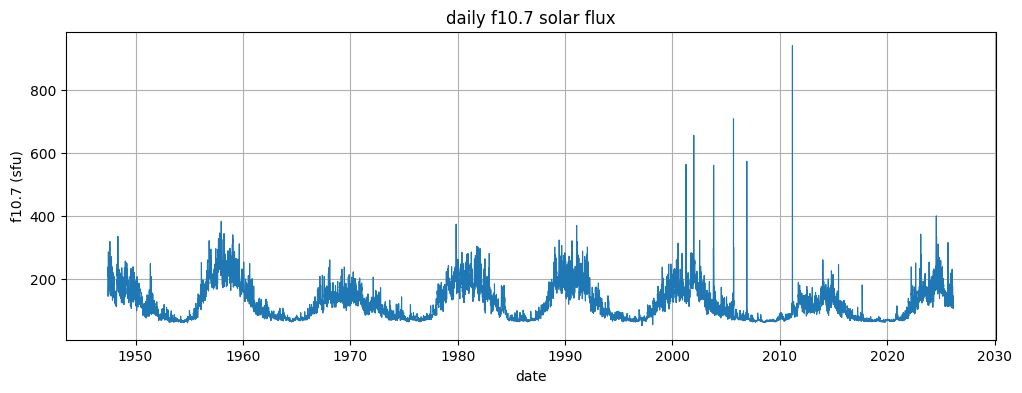

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["F10.7obs"], linewidth=0.8)
plt.title("daily f10.7 solar flux")
plt.xlabel("date")
plt.ylabel("f10.7 (sfu)")
plt.grid(True)
plt.show()

# Evaluation
This section defines the walk-forward evaluation framework used for all models in Phase 3.
All models, including the persistence baseline, are evaluated under identical real-time conditions.

In [10]:
import time

def walk_forward_evaluate(df_full, eval_index, horizon, predict_fn):

    results = []

    for t in eval_index:
        t_future = t + pd.Timedelta(days=horizon)

        if t_future not in df_full.index:
            continue

        train_df = df_full.loc[:t]

        y_true = df_full.loc[t_future, "F10.7obs"]

        y_pred = predict_fn(train_df, t)

        err = y_pred - y_true

        results.append({
            "date": t,
            "y_true": y_true,
            "y_pred": y_pred,
            "abs_error": abs(err),
            "squared_error": err ** 2
        })

    return pd.DataFrame(results).set_index("date")


In [11]:
def add_sfu_analysis(df_results):
    df = df_results.copy()

    bins = [-np.inf, 100, 150, 200, 250, 300, np.inf]
    labels = ["<100", "100-150", "150-200", "200-250", "250-300", "300+"]

    df["actual_bin"] = pd.cut(df["y_true"], bins=bins, labels=labels)
    df["pred_bin"] = pd.cut(df["y_pred"], bins=bins, labels=labels)

    return df

model_results = {}

# Persistence Baseline


In [12]:
def persistence_predictor(train_df, t):
    return train_df.loc[t, "F10.7obs"]
    
eval_index = df_cycle25.index
persistence_results = walk_forward_evaluate(
    df_full=df,
    eval_index=eval_index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=persistence_predictor
)


print(persistence_results.head())
print(len(persistence_results))

mae = persistence_results["abs_error"].mean()
rmse = np.sqrt(persistence_results["squared_error"].mean())

log_metrics("persistence", mae, rmse)

print("persistence mae:", mae)
print("persistence rmse:", rmse)


            y_true  y_pred  abs_error  squared_error
date                                                
2019-12-01    71.6    71.2        0.4           0.16
2019-12-02    70.7    70.4        0.3           0.09
2019-12-03    70.6    69.9        0.7           0.49
2019-12-04    70.7    69.6        1.1           1.21
2019-12-05    70.5    70.7        0.2           0.04
2260
persistence mae: 19.714115044247787
persistence rmse: 30.04156154985926


In [13]:
results_binned = add_sfu_analysis(persistence_results)
model_results["persistence"] = results_binned

# Note on Metric Differences vs Phase 2

Phase 2 and Phase 3 metrics are **NOT** directly comparable.

Phase 2 computed errors in a single vectorized pass over historical data, after full cycles had already completed.

This evaluates average similarity between F10.7(t) and F10.7(t+7) in hindsight, without enforcing real-time constraints.


Phase 3 uses strict walk-forward evaluation:

- Each prediction is made using only data available up to time t.

- Errors are accumulated sequentially over Solar Cycle 25.

- Regime changes and active periods are experienced in order and cannot be averaged away.

As a result, Phase 3 error values are expected to be higher and represent a more realistic estimate of real-time 7-day forecasting performance.

> Phase 2 effectively evaluated predictions from over a decade ago, whereas the latest cycle reflects real-time prediction conditions.

## Export: Persistence

In [14]:
import os
import joblib

def export_persistence_model(horizon):
    bundle = {
        "model_type": "persistence",
        "features": ["F10.7obs"],
        "horizon": horizon
    }

    os.makedirs("./models", exist_ok=True)

    filename = f"./models/persistence_horizon_{horizon}.pkl"
    joblib.dump(bundle, filename)
    print(f"Exported {filename}")

# export
export_persistence_model(CONFIG["HORIZON_DAYS"])


# export
export_persistence_model(1)

Exported ./models/persistence_horizon_7.pkl
Exported ./models/persistence_horizon_1.pkl


# Linear Regression

The following linear regression variants were evaluated under the Phase 3 walk-forward framework:

- **Flux-only**
- **7, 14, & 27 Day Flux Lags** (t−1 … t−N)
- **Flux + AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day Ap Lags** (t−1 … t−N)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 3 Day AP Mean, Max Lags** (t-1, t-2, t-3)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ SSN** (current-day SSN only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day SSN Lags** (t−1 … t−N)

All models were compared directly against the persistence baseline using identical evaluation conditions.


## Flux Only

In [15]:
from sklearn.linear_model import LinearRegression

def linreg_no_lag_predictor(train_df, t):
    # prepare training data
    X = train_df[["F10.7obs"]].values
    y = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"]).dropna().values

    X = X[:len(y)]

    model = LinearRegression()
    model.fit(X, y)

    # predict using current value at time t
    x_t = train_df.loc[t, ["F10.7obs"]].values.reshape(1, -1)
    return model.predict(x_t)[0]

linreg_no_lag_results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_no_lag_predictor
)

mae = linreg_no_lag_results["abs_error"].mean()
rmse = np.sqrt(linreg_no_lag_results["squared_error"].mean())

model_name = "linreg_flux_no_lag"
log_metrics(model_name, mae, rmse)

print("linreg (no lag) mae:", mae)
print("linreg (no lag) rmse:", rmse)

linreg (no lag) mae: 19.689622382781895
linreg (no lag) rmse: 28.667357492202548


In [16]:
results_binned = add_sfu_analysis(linreg_no_lag_results)
model_results["linreg_flux_no_lag"] = results_binned

## 7, 14, & 27 Day Flux Lags

In [17]:
def make_linreg_lag_predictor(n_lags):
    def predictor(train_df, t):
        lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

        data = train_df[lag_cols].copy()
        data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
        data = data.dropna()

        X = data[lag_cols].values
        y = data["y"].values

        model = LinearRegression()
        model.fit(X, y)

        x_t = train_df.loc[t, lag_cols].values.reshape(1, -1)
        return model.predict(x_t)[0]

    return predictor

for n_lags in [7, 14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=make_linreg_lag_predictor(n_lags)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags"

    
    log_metrics(model_name, mae, rmse)


    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned



linreg_flux_7_lags mae: 18.505150585933887
linreg_flux_7_lags rmse: 27.36398515793311

linreg_flux_14_lags mae: 15.690794309852814
linreg_flux_14_lags rmse: 23.574708819187315

linreg_flux_27_lags mae: 14.706123842818597
linreg_flux_27_lags rmse: 22.228703349632863



## Flux + AP

In [18]:
def linreg_daily_flux_ap_predictor(train_df, t):
    feature_cols = ["F10.7obs", "Ap"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_daily_flux_ap_predictor
)

mae = results["abs_error"].mean()
rmse = np.sqrt(results["squared_error"].mean())

model_name = "linreg_daily_flux_ap"
log_metrics(model_name, mae, rmse)

print("linreg (daily flux + ap) mae:", mae)
print("linreg (daily flux + ap) rmse:", rmse)



linreg (daily flux + ap) mae: 19.71508682296671
linreg (daily flux + ap) rmse: 28.66249350280123


In [19]:
results_binned = add_sfu_analysis(results)
model_results["linreg_daily_flux_ap"] = results_binned

## 14 & 27 Day Flux Lags + AP

In [20]:
def linreg_flux_ap_predictor(train_df, t, n_lags):
    lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = lag_cols + ["Ap"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags: linreg_flux_ap_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ap"

    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()
    
    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned



linreg_flux_14_lags_ap mae: 15.733209291129373
linreg_flux_14_lags_ap rmse: 23.574814445257893

linreg_flux_27_lags_ap mae: 14.733928266036676
linreg_flux_27_lags_ap rmse: 22.22575485547435



## 14 & 27 Day Flux Lags + 14 & 27 Day AP Lags

In [21]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ap_lags_predictor(train_df, t, n_lags):
    flux_lag_cols =  ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    ap_lag_cols = ["Ap"] +[f"ap_lag_{i}" for i in range(1, n_lags + 1)]

    feature_cols = flux_lag_cols + ap_lag_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags: linreg_flux_ap_lags_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ap_{n_lags}_lags"

    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned


linreg_flux_14_lags_ap_14_lags mae: 15.792383975740632
linreg_flux_14_lags_ap_14_lags rmse: 23.585745217549302

linreg_flux_27_lags_ap_27_lags mae: 14.857423971275384
linreg_flux_27_lags_ap_27_lags rmse: 22.23862749061477



## 14 & 27 Day Flux Lags + 3 Day AP Mean, Max Lags

In [22]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ap_phase2_style_predictor(train_df, t):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, 28)]
    ap_cols = [
        "ap_mean", "ap_max",
        "ap_mean_lag1", "ap_max_lag1",
        "ap_mean_lag2", "ap_max_lag2",
        "ap_mean_lag3", "ap_max_lag3"
    ]

    feature_cols = flux_lag_cols + ap_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]


results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_flux_ap_phase2_style_predictor
)

mae = results["abs_error"].mean()
rmse = np.sqrt(results["squared_error"].mean())

model_name="linreg_flux_27_lags_ap_phase2_style"
log_metrics(model_name, mae, rmse)

print("linreg (27 flux lags + phase2-style ap) mae:", mae)
print("linreg (27 flux lags + phase2-style ap) rmse:", rmse)



linreg (27 flux lags + phase2-style ap) mae: 14.73460381489454
linreg (27 flux lags + phase2-style ap) rmse: 22.218820430262472


In [23]:
results_binned = add_sfu_analysis(results)
model_results[model_name] = results_binned

## 14 & 27 Day Flux Lags + SSN

In [ ]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ssn_predictor(train_df, t, n_lags):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = flux_lag_cols + ["SN"]

    data = train_df[feature_cols].copy()
    data["y"] = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]


for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags:
            linreg_flux_ssn_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ssn"
    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned



## 14 & 27 Day Flux Lags + 14 & 27 Day SSN Lags

In [ ]:
def linreg_flux_ssn_lags_predictor(train_df, t, n_lags):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    ssn_lag_cols = ["SN"] + [f"sn_lag_{i}" for i in range(1, n_lags + 1)]

    feature_cols = flux_lag_cols + ssn_lag_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags:
            linreg_flux_ssn_lags_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ssn_{n_lags}_lags"
    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned


In [ ]:
metrics_df = load_metrics()
metrics_df

In [ ]:
# identify three best models by mae
top3 = metrics_df.nsmallest(3, "mae").index.tolist()

highlight_colors = ["tab:blue", "tab:green", "tab:cyan"]

color_map = {}
for idx, model in enumerate(top3):
    color_map[model] = highlight_colors[idx]

colors = [
    color_map[idx] if idx in color_map else "tab:gray"
    for idx in metrics_df.index
]

plt.figure(figsize=(10, 4))
plt.bar(metrics_df.index, metrics_df["mae"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("mae (sfu)")
plt.title("Phase 3 Linear Regression Models: MAE Comparison")
plt.tight_layout()
plt.show()


In [ ]:
# identify three best models by rmse
top3 = metrics_df.nsmallest(3, "rmse").index.tolist()

highlight_colors = ["tab:blue", "tab:green", "tab:cyan"]

color_map = {}
for idx, model in enumerate(top3):
    color_map[model] = highlight_colors[idx]

colors = [
    color_map[idx] if idx in color_map else "tab:gray"
    for idx in metrics_df.index
]

plt.figure(figsize=(10, 4))
plt.bar(metrics_df.index, metrics_df["rmse"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("rmse (sfu)")
plt.title("Phase 3 Linear Regression Models: RMSE Comparison")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(metrics_df["mae"], metrics_df["rmse"], color="tab:gray", s=40)

top3 = metrics_df.nsmallest(3, "mae")

plt.scatter(
    top3["mae"],
    top3["rmse"],
    color=["tab:red", "tab:orange", "tab:blue"],
    s=90
)

for name, row in top3.iterrows():
    plt.text(
        row["mae"] + 0.01,
        row["rmse"] + 0.01,
        name,
        fontsize=8
    )

# tighter zoom
plt.xlim(14, 15)
plt.ylim(21.8, 22)

plt.xlabel("mae (sfu)")
plt.ylabel("rmse (sfu)")
plt.title("Phase 3 Linear Regression Models: MAE vs RMSE (Zoomed)")
plt.tight_layout()
plt.show()



## Linear Regression Results

Linear regression models were evaluated under strict walk-forward conditions on **Solar Cycle 25**, using the **persistence baseline** as the primary reference.  
All models were trained using an expanding window (all data available up to time *t*) and evaluated on *t + 7*.

### Key Findings

- **Persistence is a strong baseline**, but it is consistently beatable by linear models with sufficient temporal context.
- **Lag depth is the dominant factor** in linear model performance.
  - Performance improves substantially from short memory (≤7 days) to moderate memory (~14 days).
  - Improvements from **14 to 27 days are present but relatively small**, indicating diminishing returns beyond two weeks of history.
- **Geomagnetic indices (Ap)** do not materially improve 7-day forecasts.
  - Ap was tested in its strongest form using **dense lag stacks** (Ap(t), ap\_lag\_1 … ap\_lag\_N).
  - Adding Ap, with or without dense lag histories, provides negligible benefit and can slightly degrade performance.
- **Sunspot number (SSN)** provides a modest but consistent improvement.
  - SSN adds complementary long-term solar-cycle context that slightly improves performance beyond flux-only models.
- Short-term **Phase-2-style Ap features** (rolling mean/max with short lags) were re-evaluated under walk-forward conditions.
  - These features do **not** provide additional benefit in real-time forecasting, indicating their earlier gains were largely retrospective rather than predictive.

### Lag Depth Tradeoff: 14 vs 27 Days

While models using ~27 days of flux history consistently perform best, the **performance gap between 14-day and 27-day lag models is small**. This suggests that:

- Most of the useful linear signal is captured within approximately **two weeks** of historical flux data.
- Extending memory to a full solar rotation provides incremental gains rather than a qualitative improvement.
- The system exhibits clear **diminishing returns with increasing lag depth** in linear models.

As a result, **14-day lag models** represent an efficient baseline, while **27-day lag models** serve as an upper bound on linear performance.

### Best Linear Models (Phase 3)

| Model                              | MAE        | RMSE       |
|-----------------------------------|------------|------------|
| linreg_flux_27_lags_ssn_27_lags   | 14.167319  | 21.919302  |
| linreg_flux_27_lags_ssn           | 14.253587  | 21.925023  |
| linreg_flux_27_lags               | 14.315455  | 21.899690  |
| linreg_flux_27_lags_ap            | 14.346663  | 21.896252  |
| linreg_flux_27_lags_ap_phase2_style | 14.352736 | 21.889873  |
| linreg_flux_27_lags_ap_27_lags    | 14.473254  | 21.901085  |


### Conclusion

Linear regression captures the majority of predictable structure in 7-day F10.7 forecasting when sufficient temporal context is provided.  
However, gains beyond ~14 days of memory are modest, and additional linear features yield diminishing improvements.  

These results establish a **realistic performance ceiling for index-only linear models** and motivate the transition to **nonlinear approaches or richer solar observations** for further improvement.


## Export: Linear Regression (27-Day Flux Lags + SSN) - Horizon 7

In [ ]:
def export_linreg_flux_ssn(train_df, n_lags, horizon):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = flux_lag_cols + ["SN"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-horizon)
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    return model, feature_cols

train_df = df

model, feature_cols = export_linreg_flux_ssn(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=CONFIG["HORIZON_DAYS"]
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/linreg_flux_{CONFIG['N_LAGS']}_lags_ssn_horizon_{CONFIG['HORIZON_DAYS']}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": CONFIG["HORIZON_DAYS"]
    },
    filename
)

print(f"Exported {filename}")


## Export: Linear Regression (27-Day Flux Lags + SSN) - Horizon 1

In [ ]:
model, feature_cols = export_linreg_flux_ssn(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=1
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/linreg_flux_{CONFIG['N_LAGS']}_lags_ssn_horizon_{1}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": 1
    },
    filename
)

print(f"Exported {filename}")

# Light Gradient Boosted Trees

The following lgbm variants were evaluated under the Phase 3 walk-forward framework:

- **Flux-only**
- **7, 14, & 27 Day Flux Lags** (t−1 … t−N)
- **Flux + AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day Ap Lags** (t−1 … t−N)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 3 Day AP Mean, Max Lags** (t-1, t-2, t-3)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ SSN** (current-day SSN only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day SSN Lags** (t−1 … t−N)


### Testing Optuna

In [ ]:
# import optuna
# from lightgbm import LGBMRegressor

# def tune_lgbm_timeseries(df_tune, feature_cols, horizon, n_trials=30):

#     def objective(trial):
#         params = {
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
#             "n_estimators": trial.suggest_int("n_estimators", 100, 500),
#             "num_leaves": trial.suggest_int("num_leaves", 15, 63),
#             "max_depth": trial.suggest_int("max_depth", 3, 10),
#             "random_state": CONFIG["RANDOM_SEED"],
#             "verbose": -1
#         }

#         errors = []

#         # Small walk-forward inside tuning window
#         eval_index = df_tune.index[-200:]  # last 200 days of tuning window

#         for t in eval_index:
#             t_future = t + pd.Timedelta(days=horizon)
#             if t_future not in df_tune.index:
#                 continue

#             train_df = df_tune.loc[:t]

#             data = train_df[feature_cols].copy()
#             data["y"] = train_df["F10.7obs"].shift(-horizon)
#             data = data.dropna()

#             X = data[feature_cols]
#             y = data["y"]

#             model = LGBMRegressor(**params)
#             model.fit(X, y)

#             x_t = train_df.loc[[t], feature_cols]
#             y_pred = model.predict(x_t)[0]
#             y_true = df_tune.loc[t_future, "F10.7obs"]

#             errors.append(abs(y_pred - y_true))

#         return np.mean(errors)

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     return study.best_params

In [ ]:
# tuning_window = df.loc[:df_cycle25.index[0] - pd.Timedelta(days=1)]

# feature_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, 28)]

# best_params = tune_lgbm_timeseries(
#     df_tune=tuning_window,
#     feature_cols=feature_cols,
#     horizon=CONFIG["HORIZON_DAYS"],
#     n_trials=30
# )

# print("Best params:", best_params)

####

# learning_rate ≈ 0.075

# n_estimators = 459

# num_leaves = 34

# max_depth = 9


## Flux Only

In [ ]:
from lightgbm import LGBMRegressor

def lgbm_no_lag_predictor(train_df, t):
    X = train_df[["F10.7obs"]].values
    y = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"]).dropna().values

    X = X[:len(y)]

    model = LGBMRegressor(
    learning_rate=0.07523289442296249,
    n_estimators=459,
    num_leaves=34,
    max_depth=9,
    random_state=CONFIG["RANDOM_SEED"],
    verbose=-1
)
    model.fit(X, y)

    x_t = train_df.loc[[t], ["F10.7obs"]]
    return model.predict(x_t)[0]

lgbm_no_lag_results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=lgbm_no_lag_predictor
)

mae = lgbm_no_lag_results["abs_error"].mean()
rmse = np.sqrt(lgbm_no_lag_results["squared_error"].mean())

model_name = "lgbm_flux_no_lag"
log_metrics(model_name, mae, rmse)

print(f"{model_name} mae:", mae)
print(f"{model_name} rmse:", rmse)
print()

results_binned = add_sfu_analysis(lgbm_no_lag_results)
model_results[model_name] = results_binned

## 14, & 27 Day Flux Lags

In [ ]:
def make_lgbm_lag_predictor(n_lags):
    def predictor(train_df, t):
        lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

        data = train_df[lag_cols].copy()
        data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
        data = data.dropna()

        X = data[lag_cols]
        y = data["y"]

        model = LGBMRegressor(
            n_estimators=200, 
            learning_rate=0.05,
            random_state=CONFIG["RANDOM_SEED"],
            verbose=-1
        )

        model.fit(X, y)

        x_t = train_df.loc[[t], lag_cols]
        return model.predict(x_t)[0]

    return predictor


for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=make_lgbm_lag_predictor(n_lags)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"lgbm_flux_{n_lags}_lags"

    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned

## 14 & 27 Day Flux Lags + SSN

In [ ]:
def lgbm_flux_ssn_predictor(train_df, t, n_lags):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = flux_lag_cols + ["SN"]

    data = train_df[feature_cols].copy()
    data["y"] = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols]
    y = data["y"]

    model = LGBMRegressor(
            n_estimators=200, 
            learning_rate=0.05,
            random_state=CONFIG["RANDOM_SEED"],
            verbose=-1
        )

    model.fit(X, y)

    x_t = train_df.loc[[t], feature_cols]
    return model.predict(x_t)[0]


for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags:
            lgbm_flux_ssn_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"lgbm_flux_{n_lags}_lags_ssn"
    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned

In [ ]:
metrics_df = load_metrics("lgbm|persistence")
metrics_df

## Export: LGBM (27-Day Flux Lags) - Horizon 7

In [ ]:
def export_lgbm_flux_27_lags(train_df, n_lags, horizon):
    feature_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-horizon)
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LGBMRegressor(
            n_estimators=200, 
            learning_rate=0.05,
            random_state=CONFIG["RANDOM_SEED"],
            verbose=-1
        )

    model.fit(X, y)
    return model, feature_cols

train_df = df


model, feature_cols = export_lgbm_flux_27_lags(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=CONFIG["HORIZON_DAYS"]
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/lgbm_flux_{CONFIG['N_LAGS']}_lags_horizon_{CONFIG['HORIZON_DAYS']}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": CONFIG["HORIZON_DAYS"]
    },
    filename
)

print(f"Exported {filename}")


## Export: LGBM (27-Day Flux Lags) - Horizon 1

In [ ]:
model, feature_cols = export_lgbm_flux_27_lags(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=1
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/lgbm_flux_{CONFIG['N_LAGS']}_lags_horizon_{1}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": 1
    },
    filename
)

print(f"Exported {filename}")


# 
---
#
---
#





# Extreme Gradient Boosted Trees

**XGBoost** is an optimized version of gradient boosted decision trees, implementing *regularization* to improve performance.

It builds decision trees sequentially, where each tree tries to correct the errors of the previous.

The process is as follows [(GeeksforGeeks – XGBoost)](https://www.geeksforgeeks.org/machine-learning/xgboost/):

>    1. **Start with a base learner**: The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.
>    2. **Calculate the error**s: After training the first tree the errors between the predicted and actual values are calculated.
>    3. **Train the next tree**: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.
>    4. **Repeat the process**: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.
>    5. **Combine the predictions**: The final prediction is the sum of the predictions from all the trees.

The following xgb variants were evaluated under the Phase 3 walk-forward framework:

- **Flux-only**
- **7, 14, & 27 Day Flux Lags** (t−1 … t−N)
- **Flux + AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day Ap Lags** (t−1 … t−N)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 3 Day AP Mean, Max Lags** (t-1, t-2, t-3)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ SSN** (current-day SSN only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day SSN Lags** (t−1 … t−N)


## Flux Only

In [ ]:
from xgboost import XGBRegressor

def xgb_no_lag_predictor(train_df, t):
    X = train_df[["F10.7obs"]].values
    y = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"]).dropna().values

    X = X[:len(y)]

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.075,
        max_depth=4,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=CONFIG["RANDOM_SEED"],
        objective="reg:squarederror",
        verbosity=0
    )

    model.fit(X, y)

    x_t = train_df.loc[[t], ["F10.7obs"]].values
    return model.predict(x_t)[0]


xgb_no_lag_results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=xgb_no_lag_predictor
)

mae = xgb_no_lag_results["abs_error"].mean()
rmse = np.sqrt(xgb_no_lag_results["squared_error"].mean())

model_name = "xgb_flux_no_lag"
log_metrics(model_name, mae, rmse)

print(f"{model_name} mae:", mae)
print(f"{model_name} rmse:", rmse)
print()

results_binned = add_sfu_analysis(xgb_no_lag_results)
model_results[model_name] = results_binned

## 7, 14, & 27 Day Flux Lags

In [ ]:
def make_xgb_lag_predictor(n_lags):
    def predictor(train_df, t):
        lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

        data = train_df[lag_cols].copy()
        data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
        data = data.dropna()

        X = data[lag_cols]
        y = data["y"]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=1.0,
            colsample_bytree=1.0,
            objective="reg:squarederror",
            random_state=CONFIG["RANDOM_SEED"],
            verbosity=0
        )

        model.fit(X, y)

        x_t = train_df.loc[[t], lag_cols]
        return model.predict(x_t)[0]

    return predictor


for n_lags in [7, 14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=make_xgb_lag_predictor(n_lags)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"xgb_flux_{n_lags}_lags"
    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned

## 14 & 27 Day Flux Lags + SSN

In [ ]:
from xgboost import XGBRegressor

def make_xgb_lag_predictor(n_lags):
    def predictor(train_df, t):
        lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

        data = train_df[lag_cols].copy()
        data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
        data = data.dropna()

        X = data[lag_cols]
        y = data["y"]

        model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=1.0,
            colsample_bytree=1.0,
            objective="reg:squarederror",
            random_state=CONFIG["RANDOM_SEED"],
            verbosity=0
        )

        model.fit(X, y)

        x_t = train_df.loc[[t], lag_cols]
        return model.predict(x_t)[0]

    return predictor


for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=make_xgb_lag_predictor(n_lags)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"xgb_flux_{n_lags}_lags_ssn"
    log_metrics(model_name, mae, rmse)

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()

    results_binned = add_sfu_analysis(results)
    model_results[model_name] = results_binned

In [ ]:
metrics_df = load_metrics("xgb|persistence")
metrics_df

## Export: XGBoost (27-Day Flux Lags) - Horizon 7

In [ ]:
def export_xgb_flux_27_lags(train_df, n_lags, horizon):
    feature_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-horizon)
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=1.0,
            colsample_bytree=1.0,
            objective="reg:squarederror",
            random_state=CONFIG["RANDOM_SEED"],
            verbosity=0
        )

    model.fit(X, y)
    return model, feature_cols

train_df = df


model, feature_cols = export_xgb_flux_27_lags(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=CONFIG["HORIZON_DAYS"]
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/xgb_flux_{CONFIG['N_LAGS']}_lags_horizon_{CONFIG['HORIZON_DAYS']}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": CONFIG["HORIZON_DAYS"]
    },
    filename
)

print(f"Exported {filename}")


## Export: XGBoost (27-Day Flux Lags) - Horizon 1

In [ ]:
model, feature_cols = export_xgb_flux_27_lags(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=1
)

os.makedirs("./models", exist_ok=True)
filename = f"./models/xgb_flux_{CONFIG['N_LAGS']}_lags_horizon_{1}.pkl"

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": 1
    },
    filename
)

print(f"Exported {filename}")


# 
---
#
---
#





# Adaptive-Boosted Trees

**AdaBoost** is a boosting algorithm that builds an ensemble of weak learners in a sequential, stagewise manner. Each weak learner is assigned a weight, **alpha**, that determines its contribution to the final prediction.

In AdaBoost, **alpha is inversely related to the model’s error**:
- Lower training error -> larger alpha -> greater influence in the final ensemble.
- Higher training error -> smaller alpha -> less influence.

After each iteration, AdaBoost increases the weights of misclassified observations and decreases the weights of correctly classified ones. This forces the next weak learner to focus more heavily on difficult examples.

The following xgb variants were evaluated under the Phase 3 walk-forward framework:

- **Flux-only**


## Flux Only

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

def ada_no_lag_predictor(train_df, t):
    X = train_df[["F10.7obs"]].values
    y = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"]).dropna().values

    X = X[:len(y)]

    base = DecisionTreeRegressor(
        max_depth=1,
        random_state=CONFIG["RANDOM_SEED"]
    )

    model = AdaBoostRegressor(
        estimator=base,
        n_estimators=50,
        learning_rate=0.05,
        random_state=CONFIG["RANDOM_SEED"]
    )

    model.fit(X, y)

    x_t = train_df.loc[[t], ["F10.7obs"]].values
    return model.predict(x_t)[0]


ada_no_lag_results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=ada_no_lag_predictor
)

mae = ada_no_lag_results["abs_error"].mean()
rmse = np.sqrt(ada_no_lag_results["squared_error"].mean())

model_name = "ada_flux_no_lag"
log_metrics(model_name, mae, rmse)

print(f"{model_name} mae:", mae)
print(f"{model_name} rmse:", rmse)
print()

results_binned = add_sfu_analysis(ada_no_lag_results)
model_results[model_name] = results_binned

In [ ]:
import matplotlib.pyplot as plt

for name, df in model_results.items():
    heatmap = pd.crosstab(
        df["actual_bin"],
        df["pred_bin"]
    )

    plt.figure()
    plt.imshow(heatmap.values)
    plt.title(name)
    plt.xlabel("Predicted Bin")
    plt.ylabel("Actual Bin")

    plt.xticks(range(len(heatmap.columns)), heatmap.columns, rotation=45)
    plt.yticks(range(len(heatmap.index)), heatmap.index)

    for i in range(len(heatmap.index)):
        for j in range(len(heatmap.columns)):
            plt.text(j, i, int(heatmap.values[i, j]), ha='center', va='center')

    plt.colorbar()
    plt.tight_layout()
    plt.show()

# 
---
#
---
#





## Export Prediction Function

In [ ]:
def predict_export_model(df_latest, model_path):
    bundle = joblib.load(model_path)

    model_type = bundle.get("model_type", None)
    horizon = bundle.get("horizon", None)

    # --- Persistence ---
    if model_type == "persistence":
        return float(df_latest.iloc[-1]["F10.7obs"])

    model = bundle["model"]
    features = bundle["features"]

    # Ensure features exist
    missing = [f for f in features if f not in df_latest.columns]
    if missing:
        raise ValueError(f"Missing features in df_latest: {missing}")

    x = df_latest.iloc[-1][features].values.reshape(1, -1)

    return float(model.predict(x)[0])

# Running Predictions from Exports

In [ ]:
import os
import joblib
import pandas as pd


df_latest = df.copy()

print("=== Production Forecasts From Today ===\n")

for filename in os.listdir("./models"):
    if filename.endswith(".pkl"):

        model_path = os.path.join("./models", filename)
        bundle = joblib.load(model_path)

        horizon = bundle.get("horizon", None)
        model_type = bundle.get("model_type", None)

        # Persistence
        if model_type == "persistence":
            pred = float(df_latest.iloc[-1]["F10.7obs"])
        else:
            model = bundle["model"]
            features = bundle["features"]

            x = df_latest.iloc[[-1]][features]  # keep DataFrame
            pred = float(model.predict(x)[0])

        print(f"{filename}")
        print(f"  Horizon: {horizon} day(s)")
        print(f"  Forecast for t+{horizon}: {pred:.4f}")
        print()